In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats

from sklearn.decomposition import PCA
from matplotlib.colors import Normalize

sns.set(context='talk')
%matplotlib widget

### load

In [16]:
pca_df      = pd.read_csv('../../results/pca_df.csv')
beh_df      = pd.read_csv('../../results/beh_df.csv')
hidden_stack = np.load('../../results/hidden_stack.npy')  # (n_nets, 60, 10)

boundaries = tuple(sorted(pca_df['boundary'].unique()))  # (0.25, 0.5, 0.75)

In [17]:
pca_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,PC1,PC2,PC3
0,0.25,b=0.25,0.047619,0,0,0.0,-0.343129,-0.006083,0.023421
1,0.25,b=0.25,0.047619,1,0,0.0,-0.343129,-0.006083,0.023421
2,0.25,b=0.25,0.095238,2,1,0.0,-0.328170,-0.001651,0.013417
3,0.25,b=0.25,0.095238,3,1,0.0,-0.328171,-0.001652,0.013417
4,0.25,b=0.25,0.142857,4,2,0.0,-0.306723,0.002879,0.007066


In [18]:
beh_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,resp,class_pred,net_idx,stim_aligned,resp_aligned,stim_rank,resp_rank
0,0.25,b=0.25,0.047619,0,0,0.0,0.169804,0.0,0,-0.202381,-0.080196,1.5,1.5
1,0.25,b=0.25,0.047619,1,0,0.0,0.169804,0.0,0,-0.202381,-0.080196,1.5,1.5
2,0.25,b=0.25,0.095238,2,1,0.0,0.182941,0.0,0,-0.154762,-0.067059,3.5,3.5
3,0.25,b=0.25,0.095238,3,1,0.0,0.182941,0.0,0,-0.154762,-0.067059,3.5,3.5
4,0.25,b=0.25,0.142857,4,2,0.0,0.196852,0.0,0,-0.107143,-0.053148,5.5,5.5


In [19]:
hidden_stack.shape

(30, 60, 10)

### PCA

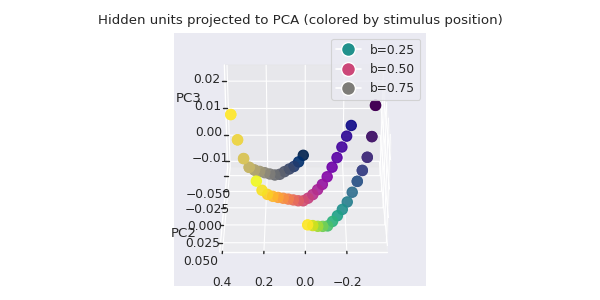

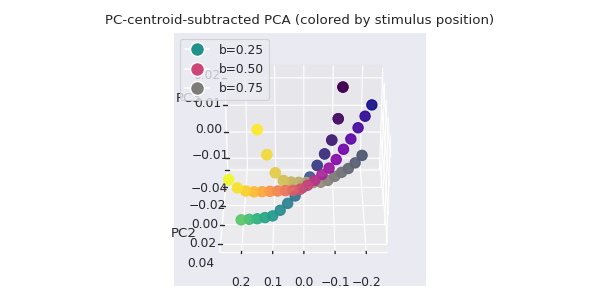

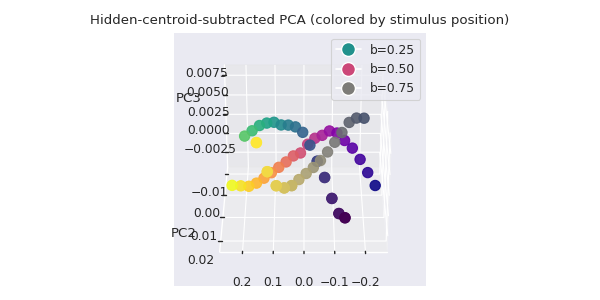

In [22]:
sns.set(context='paper')
from matplotlib.lines import Line2D

# average hidden activations across networks for each of the 60 trials
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]

# project to 3 PCs (plot 1)
pca = PCA(n_components=3)
pcs = pca.fit_transform(hidden_mean)

pca_df = pca_df.copy()
pca_df['PC1'] = pcs[:, 0]
pca_df['PC2'] = pcs[:, 1]
pca_df['PC3'] = pcs[:, 2]

# three green->yellow spectra (one per boundary)
cond_cmaps = { 0.25: plt.cm.viridis, 0.50: plt.cm.plasma, 0.75: plt.cm.cividis}

# legend handles using midpoint (0.5) color of each colormap
legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cond_cmaps[bound](0.5), markersize=10,
           label=f'b={bound:.2f}')
    for bound in boundaries
]

# ── View angle (tweak these) ──────────────────────────────────────────────────
view_elev = 30   # elevation in degrees (default matplotlib: 30)
view_azim = -270   # azimuth  in degrees (default matplotlib: -60)

# plot 1: PCA with color encoding stimulus position within each condition
fig = plt.figure(figsize=(6,3))
ax = fig.add_subplot(111, projection='3d')

for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    norm = Normalize(vmin=cond_df['stim'].min(), vmax=cond_df['stim'].max())
    colors = cond_cmaps[bound](norm(cond_df['stim'].values))

    ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9)
ax.set_title('Hidden units projected to PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles, loc='best')
plt.tight_layout()
plt.show()


# plot 2: subtract per-condition centroid in PC space (not hidden space)
pca3 = PCA(n_components=3)
pcs3 = pca3.fit_transform(hidden_mean)  # project original (uncentered) hidden to PC space

shared_norm = Normalize(vmin=pca_df['stim'].min(), vmax=pca_df['stim'].max())

pcs3_centered = pcs3.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    centroid_pc = pcs3[idx].mean(axis=0)  # [3] mean in PC space
    pcs3_centered[idx] = pcs3[idx] - centroid_pc

pca_df['PC1_pcc'] = pcs3_centered[:, 0]
pca_df['PC2_pcc'] = pcs3_centered[:, 1]
pca_df['PC3_pcc'] = pcs3_centered[:, 2]

fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')

for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    colors = cond_cmaps[bound](shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9)

ax.set_title('PC-centroid-subtracted PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles, loc='best')
plt.tight_layout()
plt.show()



# plot 3: subtract per-condition centroid in hidden-unit space, then project
hidden_centered = hidden_mean.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    centroid = hidden_mean[idx].mean(axis=0)          # [10] mean hidden vec
    hidden_centered[idx] = hidden_mean[idx] - centroid

pca2 = PCA(n_components=3)
pcs2 = pca2.fit_transform(hidden_centered)

pca_df['PC1_c'] = pcs2[:, 0]
pca_df['PC2_c'] = pcs2[:, 1]
pca_df['PC3_c'] = pcs2[:, 2]

fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')

for bound in boundaries:
    # if bound==.25: continue
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    colors = cond_cmaps[bound](shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1_c'], cond_df['PC2_c'], cond_df['PC3_c'], c=colors, s=55, alpha=0.9)

ax.set_title('Hidden-centroid-subtracted PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles, loc='best')
plt.tight_layout()
plt.show()



## single-unit

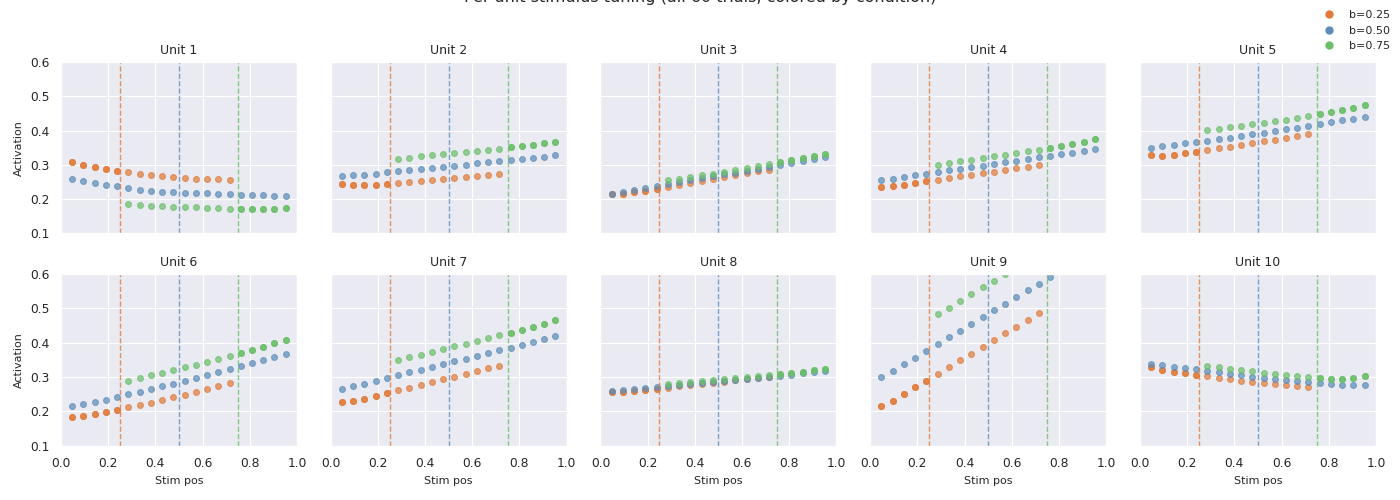

In [21]:
# build tuning_df
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]
n_units = hidden_mean.shape[1]
cond_colors = {0.25: '#e07b39', 0.50: '#5b8db8', 0.75: '#6abf69'}

tuning_df = pca_df[['boundary', 'stim']].copy().reset_index(drop=True)
for i in range(n_units):
    tuning_df[f'unit_{i}'] = hidden_mean[:, i]

# 5×2 per-unit grid
fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    for bound in boundaries:
        cond_df = tuning_df[tuning_df['boundary'] == bound].sort_values('stim')
        ax.scatter(cond_df['stim'], cond_df[f'unit_{i}'],
                   color=cond_colors[bound], s=18, alpha=0.7)
        ax.axvline(bound, color=cond_colors[bound], linestyle='--', linewidth=1, alpha=0.8)
    ax.set_title(f'Unit {i+1}', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0.1, 0.6)
    if i % 5 == 0:
        ax.set_ylabel('Activation', fontsize=8)
    if i >= 5:
        ax.set_xlabel('Stim pos', fontsize=8)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cond_colors[b],
               markersize=7, label=f'b={b:.2f}')
    for b in boundaries
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=8, frameon=False,
           bbox_to_anchor=(1.0, 1.0))
plt.suptitle('Per-unit stimulus tuning (all 60 trials, colored by condition)', y=1.02)
plt.tight_layout()
plt.show()

### population

questions to ask yourself:
1. what is population analysis buying you that single-neuron doesn't?
2. what is special about your setup compared to ramon's preprint? Yes, contexts are probably, unsurprisingly, going to be ordered. But perhaps, there is some asymmetry of the 2 compressed contexts w.r.t baseline? A sort of hierarchical arragnement of contexts, where axis 1 reads out ordering, while axis 2 reads is the reflection line for compressed contexts? More realistically, there is only going to be one axis, unless the brain really cares about baseline vs not.. and if there is axis 2, it would support the mixed-selectivity, non-linearity hypothesis.